In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SCHECHTER: α=0, D0: Loaded
SCHECHTER: α=0, 5D0: Loaded
SCHECHTER: α=0, 25D0: Loaded
SCHECHTER: α=-2, D0: Loaded
SCHECHTER: α=-2, 5D0: Loaded
SCHECHTER: α=-2, 25D0: Loaded
SCHECHTER: α=-4, D0: Loaded
SCHECHTER: α=-4, 5D0: Loaded
SCHECHTER: α=-4, 25D0: Loaded
STD: α=0, D0: Loaded
STD: α=0, 5D0: Loaded
STD: α=0, 25D0: Loaded
STD: α=-2, D0: Loaded
STD: α=-2, 5D0: Loaded
STD: α=-2, 25D0: Loaded
STD: α=-4, D0: Loaded
STD: α=-4, 5D0: Loaded
STD: α=-4, 25D0: Loaded


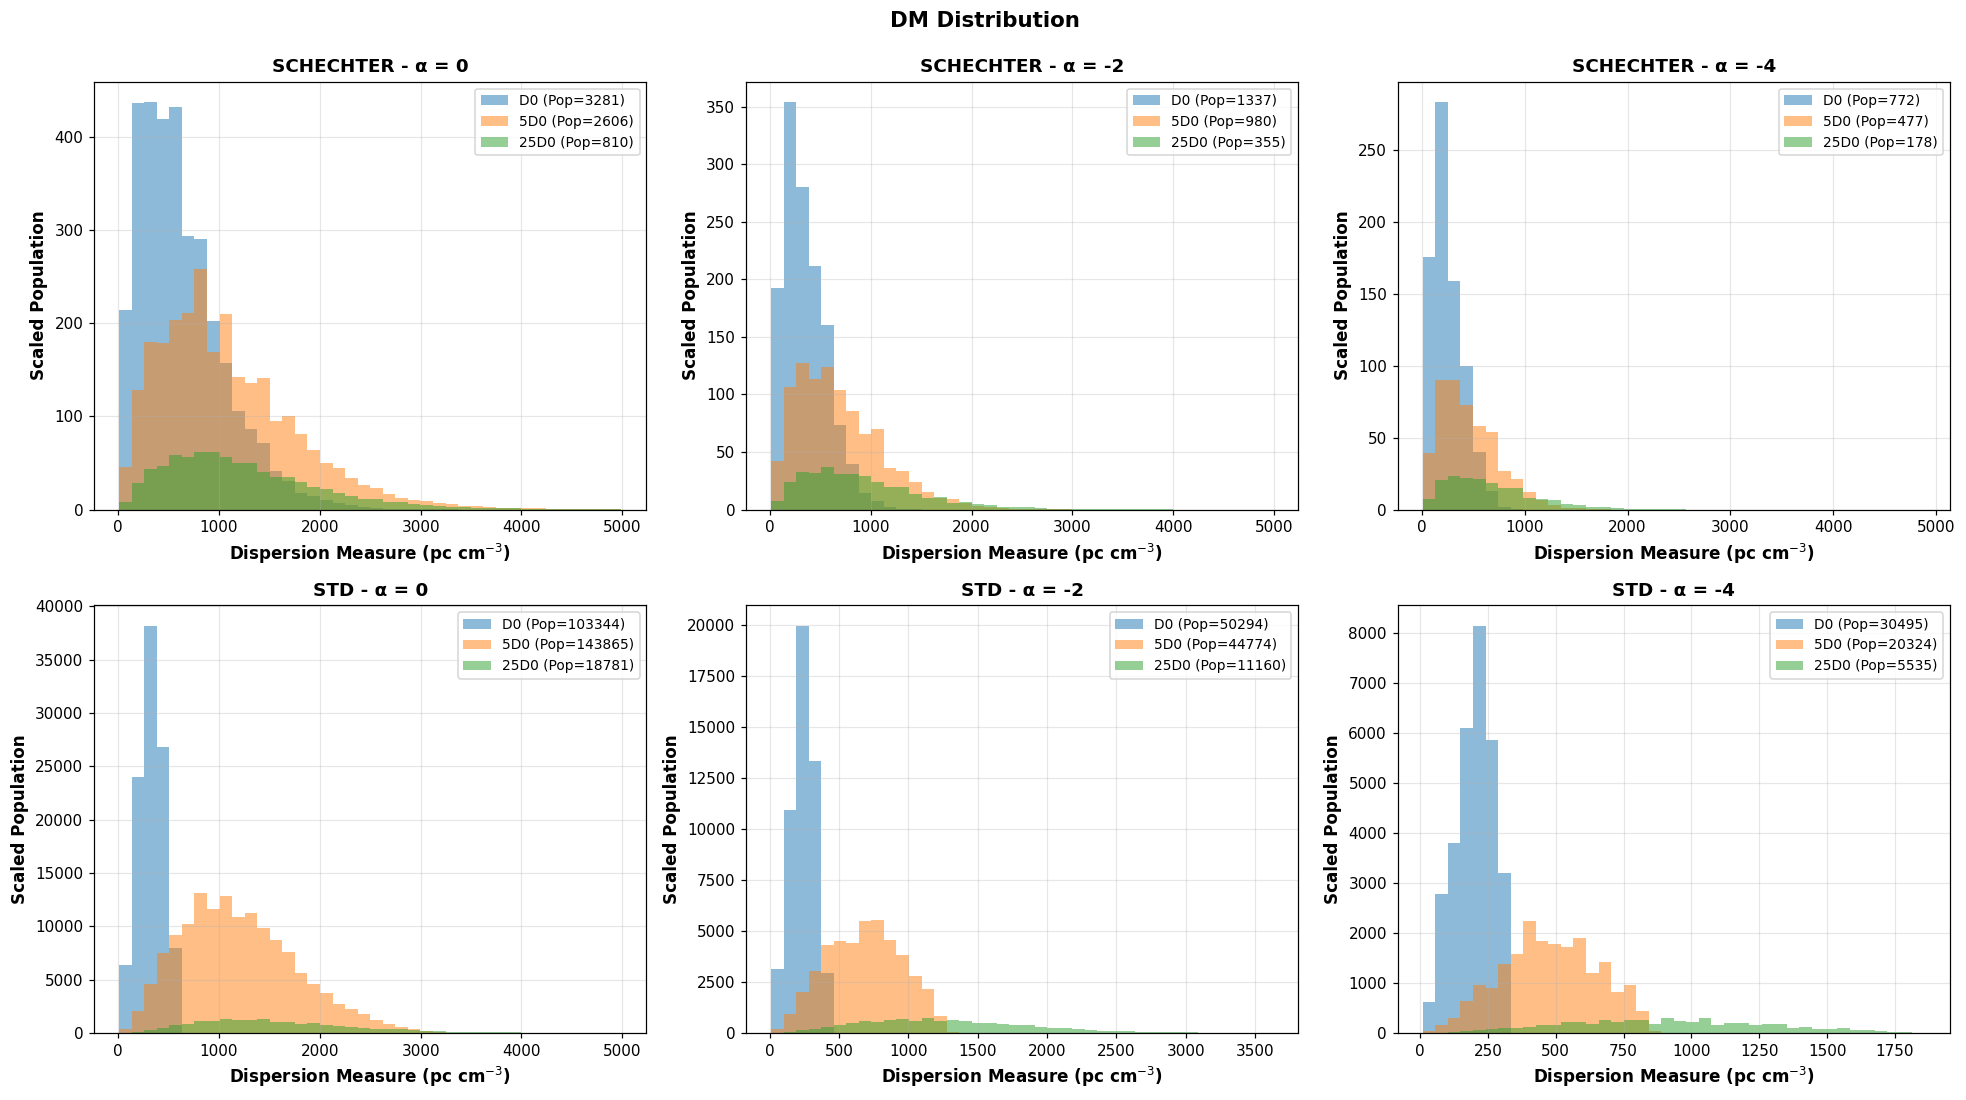


2x3 population-weighted DM distribution plot generated (Schechter vs Std)!


In [2]:

# ============================================================================
# LOAD DATA FOR BOTH LUMINOSITY FUNCTIONS - COMBINED 2x3 PLOT
# ============================================================================

lumi_funcs = ["schechter", "std"]
path = 'DM_distribution_new'

alpha_values = [0, -2, -4]
telescopes = ["d0", "5d0", "25d0"]
colors = {"d0": "tab:blue", "5d0": "tab:orange", "25d0": "tab:green"}

# Load all data for both luminosity functions
all_data = {}
for lumi_func in lumi_funcs:
    all_data[lumi_func] = {}
    for alpha in alpha_values:
        all_data[lumi_func][alpha] = {}
        for telescope in telescopes:
            try:
                df = pd.read_csv(f'{path}/DM_{telescope}_alpha{alpha}_{lumi_func}_scaled.csv')
                all_data[lumi_func][alpha][telescope] = {
                    'z': df['z'].values,
                    'DM': 1000 * df['z'].values,
                    'population': df['n_total_population_scaled'].values
                }
                print(f"{lumi_func.upper()}: α={alpha}, {telescope.upper()}: Loaded")
            except FileNotFoundError:
                print(f"{lumi_func.upper()}: α={alpha}, {telescope.upper()}: File not found")

# ============================================================================
# CREATE 2x3 PLOT - DM SCALED BY POPULATION (Schechter top, Std bottom)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=110)

fig.suptitle('DM Distribution', 
             fontsize=14, fontweight='bold', y=0.995)

# Row 0: Schechter, Row 1: Std
for row_idx, lumi_func in enumerate(lumi_funcs):
    for col_idx, alpha in enumerate(alpha_values):
        ax = axes[row_idx, col_idx]
        data = all_data[lumi_func]
        
        # Define common bins for this alpha
        all_DMs = np.concatenate([data[alpha][t]['DM'] for t in telescopes if t in data[alpha]])
        dm_min = all_DMs.min()
        dm_max = all_DMs.max()
        common_bins = np.linspace(dm_min, dm_max, 41)
        
        # Plot weighted histograms for all three telescopes
        for telescope in telescopes:
            if telescope in data[alpha]:
                DM = data[alpha][telescope]['DM']
                population = data[alpha][telescope]['population']
                total_pop = population.sum()
                
                ax.hist(DM, bins=common_bins, weights=population, alpha=0.5, 
                        label=f'{telescope.upper()} (Pop={total_pop:.0f})', 
                        color=colors[telescope])
        
        ax.set_xlabel('Dispersion Measure (pc cm$^{-3}$)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Scaled Population', fontsize=11, fontweight='bold')
        ax.set_title(f'{lumi_func.upper()} - α = {alpha}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n2x3 population-weighted DM distribution plot generated (Schechter vs Std)!")




✓ Loaded data for 624 combinations


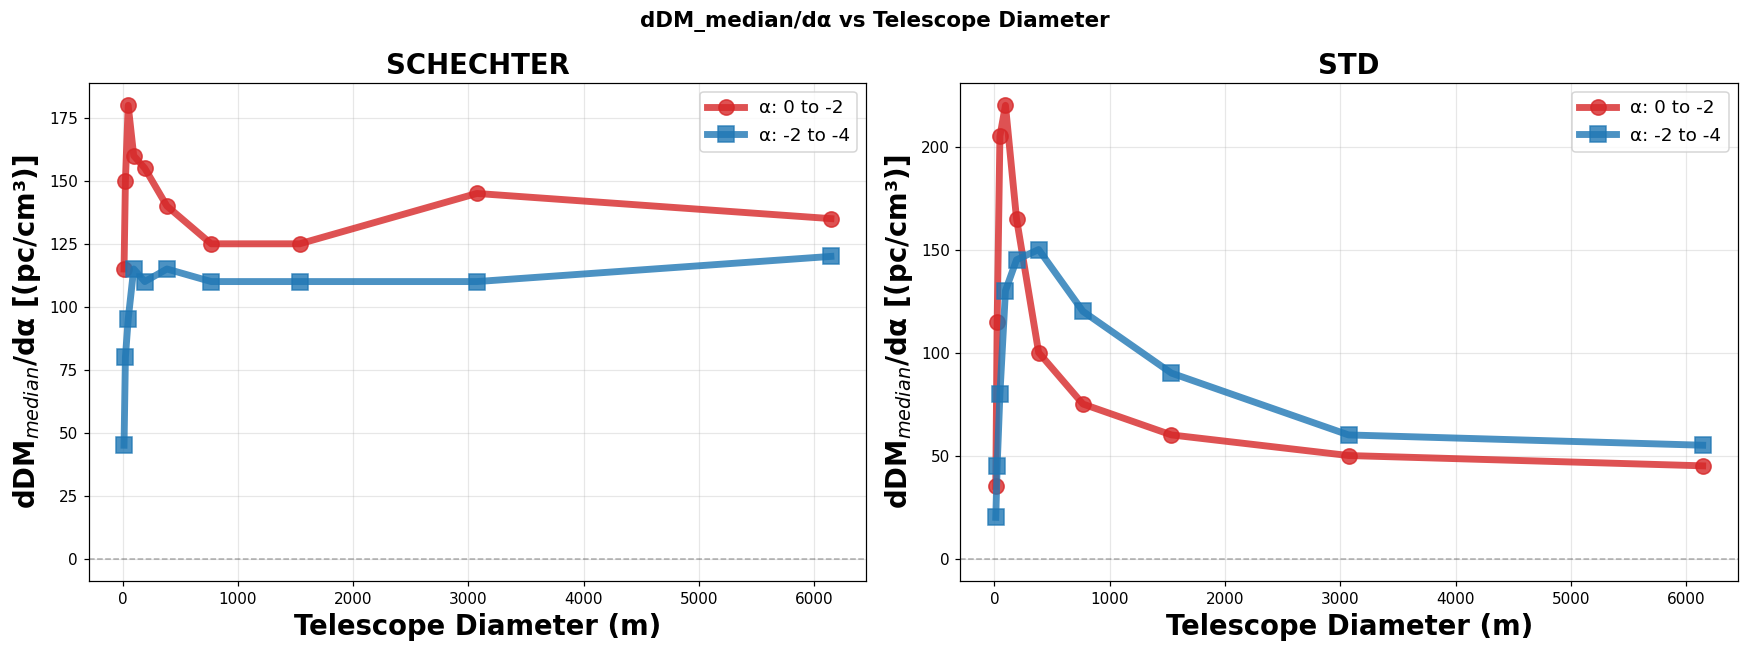

✓ dDM_median/dα vs Diameter plot generated


In [3]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = 'DM_distribution_new'
lumi_funcs = ["schechter", "std"]
alpha_values = [0, -2, -4]
diameter_range = range(1, 1024)  # 1D0 to 100D0

# ============================================================================
# LOAD DATA FOR ALL DIAMETERS
# ============================================================================

all_data_full = {}

for lumi_func in lumi_funcs:
    all_data_full[lumi_func] = {}
    for alpha in alpha_values:
        all_data_full[lumi_func][alpha] = {}
        for diameter_mult in diameter_range:
            telescope_name = f"{diameter_mult}d0"
            try:
                df = pd.read_csv(f'{path}/DM_{telescope_name}_alpha{alpha}_{lumi_func}_scaled.csv')
                
                # Calculate DM_median and DM_peak
                DM = 1000 * df['z'].values
                pop = df['n_total_population_scaled'].values
                
                # Weighted median
                sorted_indices = np.argsort(DM)
                sorted_DM = DM[sorted_indices]
                sorted_pop = pop[sorted_indices]
                cumsum_pop = np.cumsum(sorted_pop)
                if len(cumsum_pop) > 0 and cumsum_pop[-1] > 0:
                    median_idx = np.where(cumsum_pop >= cumsum_pop[-1]/2)[0]
                    if len(median_idx) > 0:
                        DM_median = sorted_DM[median_idx[0]]
                    else:
                        DM_median = sorted_DM[0]
                else:
                    DM_median = 0
                
                # Peak population DM
                if len(pop) > 0:
                    peak_idx = np.argmax(pop)
                    DM_peak = DM[peak_idx]
                else:
                    DM_peak = 0
                
                all_data_full[lumi_func][alpha][diameter_mult] = {
                    'diameter_m': diameter_mult * 12,
                    'DM_median': DM_median,
                    'DM_peak': DM_peak,
                    'total_population': pop.sum()
                }
            except FileNotFoundError:
                pass

print(f"✓ Loaded data for {sum(len(d) for a in all_data_full.values() for d in a.values())} combinations")



# ============================================================================
# PLOT 1: dDM_median/dα vs Telescope Diameter
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=110)
fig.suptitle('dDM_median/dα vs Telescope Diameter', fontsize=14, fontweight='bold')

# Filter to every
diameter_mults = [2**i for i in range(10)]
diameters_m = [d * 12 for d in diameter_mults]

for plot_idx, lumi_func in enumerate(lumi_funcs):
    ax = axes[plot_idx]
    
    # Segment 1: α = 0 to -2
    derivatives_seg1 = []
    for d_mult in diameter_mults:
        dm_0 = all_data_full[lumi_func][0][d_mult]['DM_median']
        dm_minus2 = all_data_full[lumi_func][-2][d_mult]['DM_median']
        deriv = (dm_minus2 - dm_0) / (-2 - 0)
        derivatives_seg1.append(deriv)
    
    # Segment 2: α = -2 to -4
    derivatives_seg2 = []
    for d_mult in diameter_mults:
        dm_minus2 = all_data_full[lumi_func][-2][d_mult]['DM_median']
        dm_minus4 = all_data_full[lumi_func][-4][d_mult]['DM_median']
        deriv = (dm_minus4 - dm_minus2) / (-4 - (-2))
        derivatives_seg2.append(deriv)
    
    ax.plot(diameters_m, derivatives_seg1, 'o-', color='tab:red', 
           linewidth=4.5, markersize=10, label='α: 0 to -2', alpha=0.8)
    ax.plot(diameters_m, derivatives_seg2, 's-', color='tab:blue', 
           linewidth=4.5, markersize=10, label='α: -2 to -4', alpha=0.8)
    
    ax.axhline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_xlabel('Telescope Diameter (m)', fontsize=18, fontweight='bold')
    ax.set_ylabel('dDM$_{median}$/dα [(pc/cm³)]', fontsize=18, fontweight='bold')
    # ax.set_xticks(fontsize=12)
    # ax.set_yticks(fontsize=12)
    ax.set_title(f'{lumi_func.upper()}', fontsize=18, fontweight='bold')
    ax.legend(fontsize=12, loc='upper right', frameon=True)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ dDM_median/dα vs Diameter plot generated")



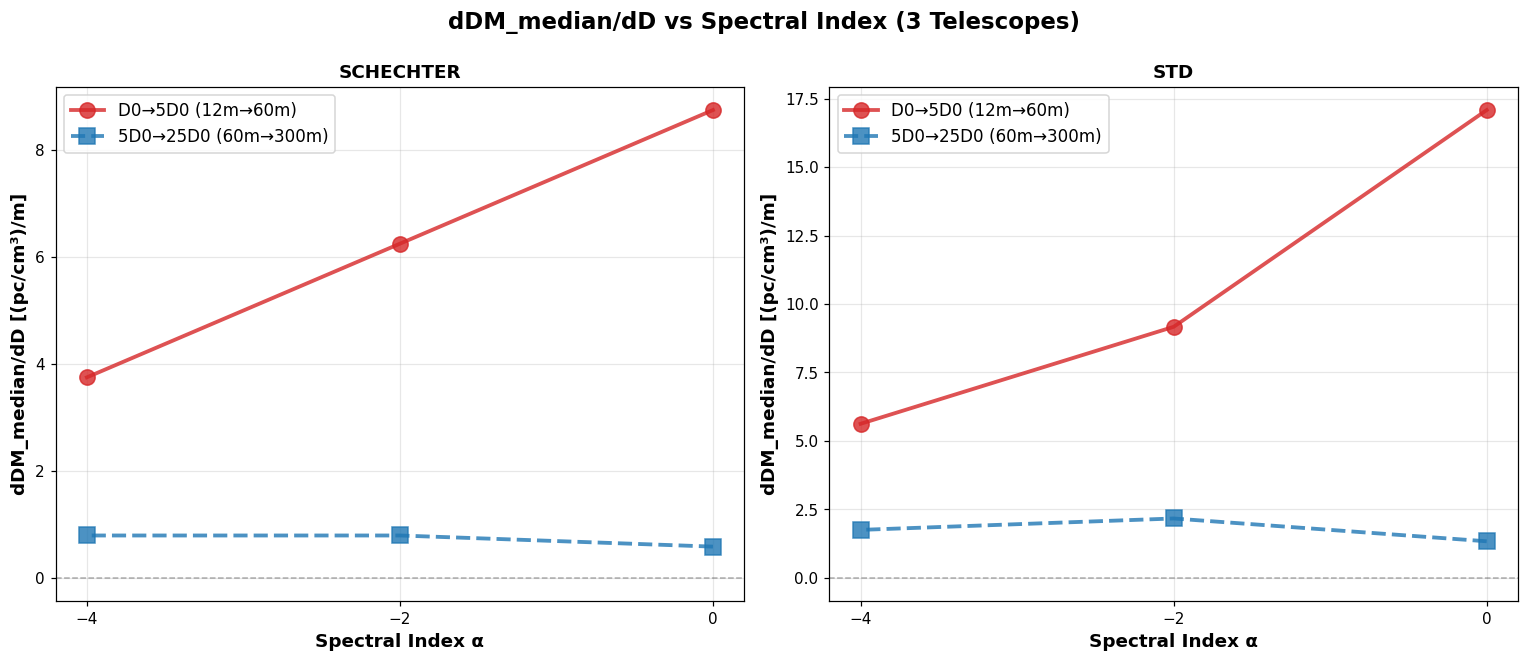

✓ dDM_median/dD vs α plot generated


In [4]:
# ============================================================================
# PLOT dDM_median/dD vs α (DERIVATIVE W.R.T. DIAMETER)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=110)
fig.suptitle('dDM_median/dD vs Spectral Index (3 Telescopes)', 
             fontsize=15, fontweight='bold', y=0.995)

telescopes_3 = ["d0", "5d0", "25d0"]
tel_mult_map = {"d0": 1, "5d0": 5, "25d0": 25}
diameters_3 = [12, 60, 300]
colors_3 = {"d0": "tab:blue", "5d0": "tab:orange", "25d0": "tab:green"}
labels_3 = {"d0": "D0→5D0", "5d0": "5D0→25D0"}

for plot_idx, lumi_func in enumerate(lumi_funcs):
    ax = axes[plot_idx]
    
    # Compute dDM_median/dD for two segments: D0-5D0 and 5D0-25D0
    derivatives_01 = []  # D0 to 5D0
    derivatives_12 = []  # 5D0 to 25D0
    
    for alpha in alpha_values:
        # Get DM_median for each telescope
        dm_d0 = all_data_full[lumi_func][alpha][1]['DM_median']
        dm_5d0 = all_data_full[lumi_func][alpha][5]['DM_median']
        dm_25d0 = all_data_full[lumi_func][alpha][25]['DM_median']
        
        # Compute derivatives
        ddm_d0_5d0 = (dm_5d0 - dm_d0) / (60 - 12)  # (pc/cm³) per meter
        ddm_5d0_25d0 = (dm_25d0 - dm_5d0) / (300 - 60)
        
        derivatives_01.append(ddm_d0_5d0)
        derivatives_12.append(ddm_5d0_25d0)
    
    # Plot both segments
    ax.plot(alpha_values, derivatives_01, 'o-', color='tab:red', 
            linewidth=2.5, markersize=10, label='D0→5D0 (12m→60m)', alpha=0.8)
    ax.plot(alpha_values, derivatives_12, 's--', color='tab:blue', 
            linewidth=2.5, markersize=10, label='5D0→25D0 (60m→300m)', alpha=0.8)
    
    ax.axhline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_xlabel('Spectral Index α', fontsize=12, fontweight='bold')
    ax.set_ylabel('dDM_median/dD [(pc/cm³)/m]', fontsize=12, fontweight='bold')
    ax.set_title(f'{lumi_func.upper()}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=11, loc='best', frameon=True)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(alpha_values)

plt.tight_layout()
plt.show()

print("✓ dDM_median/dD vs α plot generated")

In [5]:
# ============================================================================
# PRINT PEAK DM AND MEDIAN DM FOR ALL DATASETS
# ============================================================================

import pandas as pd
import numpy as np

path = 'DM_distribution_new'
lumi_funcs = ["schechter", "std"]
alpha_values = [0, -2, -4]
telescopes = ["d0", "5d0", "25d0"]
diameters = {"d0": 12, "5d0": 60, "25d0": 300}

print("\n" + "="*130)
print("PEAK DM AND MEDIAN DM FOR ALL DATASETS")
print("="*130)

for lumi_func in lumi_funcs:
    print(f"\n{'='*130}")
    print(f"LUMINOSITY FUNCTION: {lumi_func.upper()}")
    print(f"{'='*130}")
    
    for alpha in alpha_values:
        print(f"\n  Spectral Index α = {alpha}")
        print(f"  {'-'*125}")
        print(f"  {'Telescope':<15} {'Diameter (m)':<15} {'DM_median (pc/cm³)':<30} {'DM_peak (pc/cm³)':<30}")
        print(f"  {'-'*125}")
        
        for telescope in telescopes:
            try:
                df = pd.read_csv(f'{path}/DM_{telescope}_alpha{alpha}_{lumi_func}_scaled.csv')
                DM = 1000 * df['z'].values
                pop = df['n_total_population_scaled'].values
                
                # Weighted median
                sorted_indices = np.argsort(DM)
                sorted_DM = DM[sorted_indices]
                sorted_pop = pop[sorted_indices]
                cumsum_pop = np.cumsum(sorted_pop)
                median_idx = np.where(cumsum_pop >= cumsum_pop[-1]/2)[0][0]
                DM_median = sorted_DM[median_idx]
                
                # Peak population DM
                peak_idx = np.argmax(pop)
                DM_peak = DM[peak_idx]
                
                print(f"  {telescope.upper():<15} {diameters[telescope]:<15} {DM_median:<30.4f} {DM_peak:<30.4f}")
                
            except FileNotFoundError:
                print(f"  {telescope.upper():<15} {diameters[telescope]:<15} {'N/A':<30} {'N/A':<30}")

print(f"\n{'='*130}")
print("END OF REPORT")
print(f"{'='*130}\n")


PEAK DM AND MEDIAN DM FOR ALL DATASETS

LUMINOSITY FUNCTION: SCHECHTER

  Spectral Index α = 0
  -----------------------------------------------------------------------------------------------------------------------------
  Telescope       Diameter (m)    DM_median (pc/cm³)             DM_peak (pc/cm³)              
  -----------------------------------------------------------------------------------------------------------------------------
  D0              12              540.0000                       360.0000                      
  5D0             60              960.0000                       830.0000                      
  25D0            300             1100.0000                      740.0000                      

  Spectral Index α = -2
  -----------------------------------------------------------------------------------------------------------------------------
  Telescope       Diameter (m)    DM_median (pc/cm³)             DM_peak (pc/cm³)              
  -------------

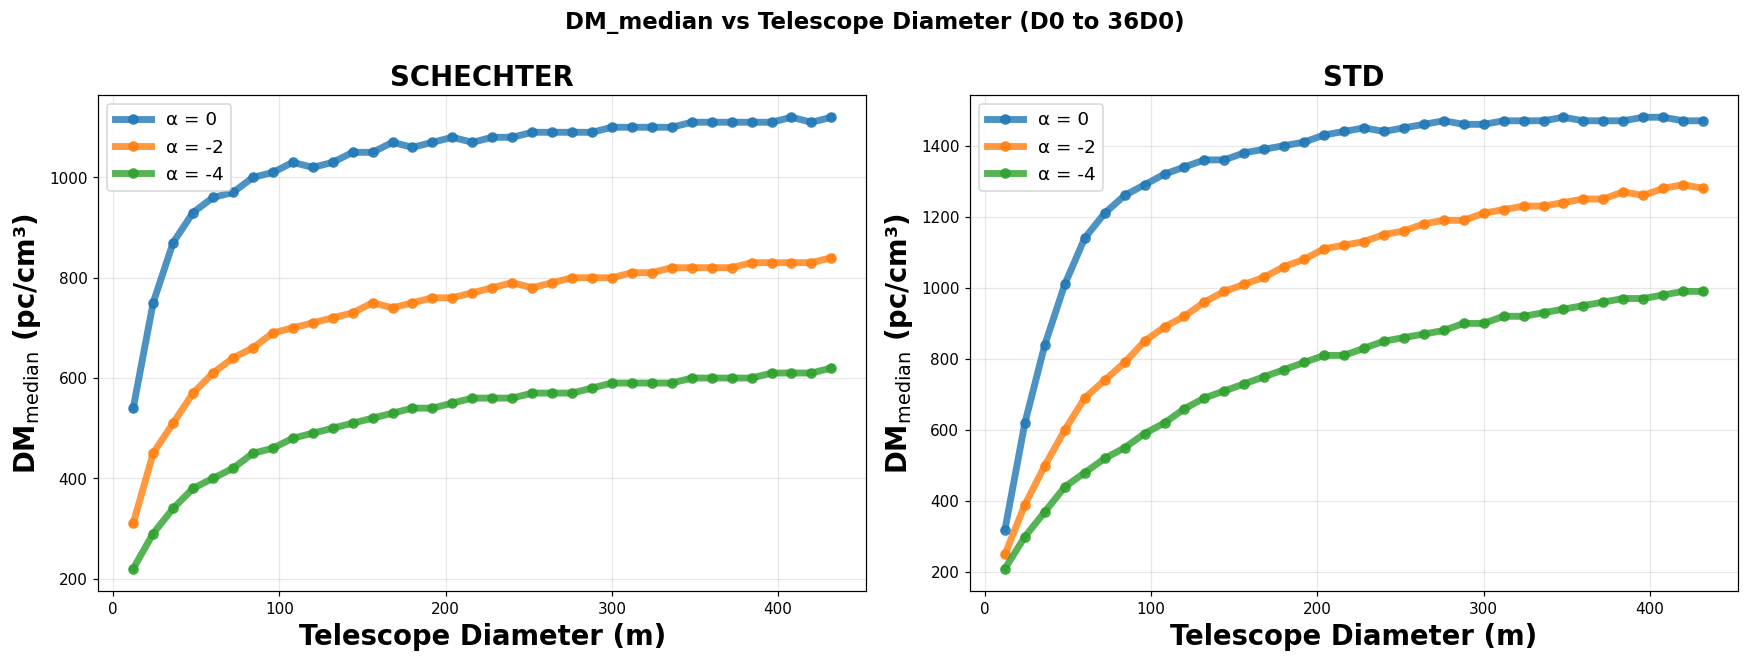

✓ DM_median vs Diameter plot generated (D0 to 36D0, α = 0, -2, -4)


In [6]:
# ============================================================================
# PLOT DM_median vs Diameter (D0 to 36D0) for Different Alpha Values
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=110)
fig.suptitle('DM_median vs Telescope Diameter (D0 to 36D0)', 
             fontsize=15, fontweight='bold', y=0.995)

# Get diameter range: D0 to 36D0 (1 to 36)
diameter_range_plot = range(1, 37)
diameters_m_plot = [d * 12 for d in diameter_range_plot]

colors_alpha = {0: 'tab:blue', -2: 'tab:orange', -4: 'tab:green'}
labels_alpha = {0: 'α = 0', -2: 'α = -2', -4: 'α = -4'}

for plot_idx, lumi_func in enumerate(lumi_funcs):
    ax = axes[plot_idx]
    
    for alpha in alpha_values:
        # Collect DM_median for each diameter
        dm_medians = []
        diameters_available = []
        
        for d_mult in diameter_range_plot:
            if d_mult in all_data_full[lumi_func][alpha]:
                dm_med = all_data_full[lumi_func][alpha][d_mult]['DM_median']
                dm_medians.append(dm_med)
                diameters_available.append(d_mult * 12)
        
        # Plot the curve
        ax.plot(diameters_available, dm_medians, 'o-', 
                color=colors_alpha[alpha], linewidth=4.5, markersize=6,
                label=labels_alpha[alpha], alpha=0.8)
    
    ax.set_xlabel('Telescope Diameter (m)', fontsize=18, fontweight='bold')
    ax.set_ylabel('DM$_{\\rm median}$ (pc/cm³)', fontsize=18, fontweight='bold')
    ax.set_title(f'{lumi_func.upper()}', fontsize=18, fontweight='bold')
    ax.legend(fontsize=12, loc='best', frameon=True)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ DM_median vs Diameter plot generated (D0 to 36D0, α = 0, -2, -4)")